In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('Downloads/placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df=df.iloc[:,1:]

In [6]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
 df.shape

(100, 3)

#### Steps:

### 1.Preprocess + EDA + Feature Selection
### 2.Extract input and output cols
### 3.Scale the values
### 4.Train test split
### 5.Train the model
### 6.Evaluate the model/model selection
### 7.Deploy the model

In [9]:
import matplotlib.pyplot as plt

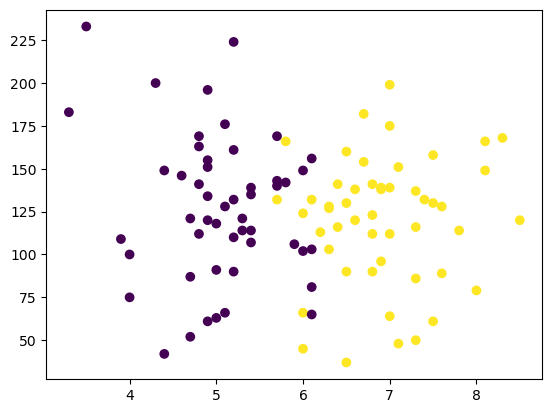

In [11]:
#EDA
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [12]:
# Drop into x and y values
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [13]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [14]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [15]:
y.shape

(100,)

In [16]:
X.shape

(100, 2)

In [18]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [19]:
X_train

,cgpa,iq
37,8.1,149.0
34,4.8,163.0
58,8.0,79.0
71,6.1,132.0
75,4.8,169.0
...,...,...
5,7.1,48.0
83,7.5,130.0
1,5.9,106.0
2,5.3,121.0


In [21]:
y_train

37    1
34    0
58    1
71    1
75    0
     ..
5     1
83    1
1     0
2     0
17    0
Name: placement, Length: 90, dtype: int64

In [23]:
!pip install StandardScalar

ERROR: Could not find a version that satisfies the requirement StandardScalar (from versions: none)
ERROR: No matching distribution found for StandardScalar


In [24]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler=StandardScaler()

In [27]:
X_train=scaler.fit_transform(X_train)

In [28]:
X_train

array([[ 1.76835763,  0.62196793],
       [-1.11736883,  0.97867234],
       [ 1.68091138, -1.16155412],
       [ 0.0194325 ,  0.18882686],
       [-1.11736883,  1.13154566],
       [ 0.28177127,  0.41813684],
       [ 1.06878758, -0.98320192],
       [ 0.6315563 , -0.32075087],
       [ 0.80644881,  1.28441898],
       [ 0.54411004,  1.46277118],
       [ 0.10687876, -0.29527198],
       [ 0.28177127, -0.21883532],
       [ 1.50601886, -0.2697931 ],
       [ 0.19432501, -0.55006085],
       [-0.06801376, -2.02783626],
       [-1.11736883, -0.32075087],
       [-1.20481509, -1.84948406],
       [-0.24290627,  0.44361572],
       [ 0.36921753,  0.90223568],
       [ 0.80644881,  0.36717906],
       [ 0.45666378, -0.11691978],
       [ 1.06878758, -0.21883532],
       [ 0.80644881,  1.89591225],
       [ 1.33112635, -0.90676526],
       [-1.81693889, -0.62649751],
       [-1.02992258, -1.62017408],
       [-0.94247632, -0.16787755],
       [-0.33035253,  0.18882686],
       [-1.90438514,

In [49]:
y_train

37    1
34    0
58    1
71    1
75    0
     ..
5     1
83    1
1     0
2     0
17    0
Name: placement, Length: 90, dtype: int64

In [29]:
X_test=scaler.transform(X_test)

In [30]:
X_test

array([[ 0.36921753,  0.13786909],
       [-1.02992258,  0.23978463],
       [-0.33035253,  0.39265795],
       [-0.59269129,  0.36717906],
       [-0.94247632, -1.56921631],
       [-0.85503006, -1.49277965],
       [-0.76758381,  0.18882686],
       [-1.81693889, -1.26346967],
       [-1.55460012,  1.92139114],
       [-0.06801376, -1.49277965]])

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
clf=LogisticRegression()

In [33]:
#model_training
clf.fit(X_train,y_train)

LogisticRegression()

In [39]:
#model evaluation :Accuracy
y_pred=clf.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1], dtype=int64)

In [40]:
y_test

57    1
40    0
36    0
12    0
7     0
9     0
19    0
68    0
95    0
45    1
Name: placement, dtype: int64

In [42]:
from sklearn.metrics import accuracy_score

In [43]:
accuracy_score(y_test,y_pred)

1.0

In [44]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

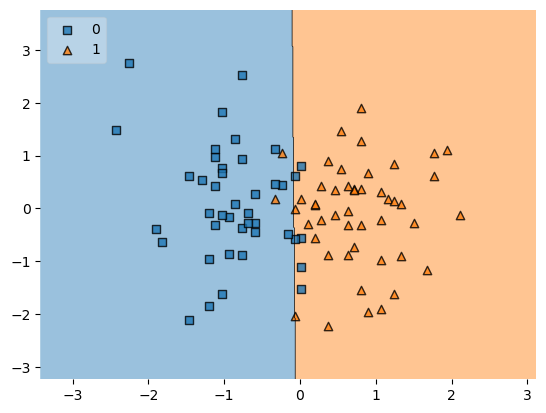

In [50]:
plot_decision_regions(X_train,y_train.values,clf=clf,legend=2)

In [51]:
# converts obj to file
import pickle

In [52]:
pickle.dump(clf,open('model.pkl','wb'))